In [27]:
import pandas as pd
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('s7.csv')

imgs_folder = 'data/mskcc/images'


df.head()

,Unnamed: 0,isic_id,dermoscopic_type,img_l,img_a,img_b,img_ita,tag_id,type,anatomic_site,...,a_3,average_a,b_1,b_2,b_3,average_b,ita_1,ita_2,ita_3,average_ita
0,1,ISIC_6369402,NP-C,66.64,14.82,-5.97,-70.263331,104514,normal-skin,upper back,...,14.0,14.33,11,11.0,10.0,10.66,53,52.0,56.0,53.66
1,2,ISIC_6052854,P-C,67.81,13.69,1.41,85.473392,104514,normal-skin,upper back,...,14.0,14.33,11,11.0,10.0,10.66,53,52.0,56.0,53.66
2,3,ISIC_7075171,P-NC,64.19,17.55,1.44,84.205466,104514,normal-skin,upper back,...,14.0,14.33,11,11.0,10.0,10.66,53,52.0,56.0,53.66
3,4,ISIC_5473699,NP-NC,63.70,18.36,-7.77,-60.440118,104514,normal-skin,upper back,...,14.0,14.33,11,11.0,10.0,10.66,53,52.0,56.0,53.66
4,5,ISIC_3868399,P-C,70.05,10.21,1.82,84.813301,105266,normal-skin,upper chest,...,9.0,8.66,12,12.0,11.0,11.66,48,50.0,49.0,49.00


Color in image (LAB):  [np.float64(146.36999999999998) np.float64(140.69) np.float64(129.39)]
Physical color (LAB):  [np.float64(160.64999999999998) np.float64(130.33) np.float64(150.0)]
Correction value (LAB):  [np.float64(1.0975609756097562) np.float64(0.9263629255810648)
 np.float64(1.159285879897983)]


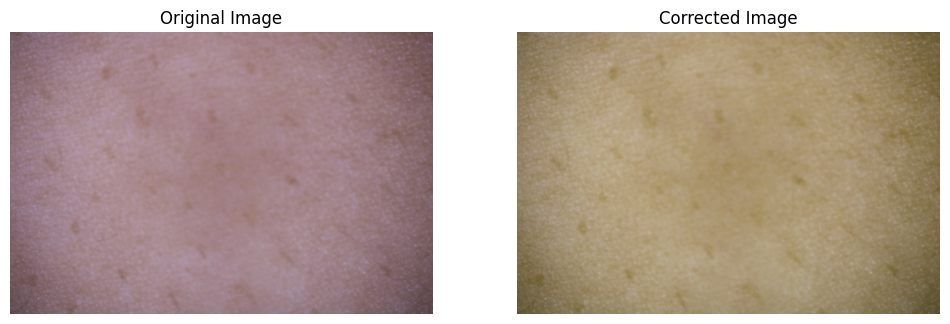

In [ ]:
img_idx = 70

img_name = df.iloc[img_idx]['isic_id'] + '.jpg'
img_path = os.path.join(imgs_folder, img_name)
img = cv.imread(img_path)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

color_in_img = df.iloc[img_idx][['img_l', 'img_a', 'img_b']].values
color_physical = df.iloc[img_idx][['average_l', 'average_a', 'average_b']].values

# map to openCV LAB range
color_in_img[0] = color_in_img[0] * (255 / 100)
color_in_img[1] = color_in_img[1] + 128
color_in_img[2] = color_in_img[2] + 128

color_physical[0] = color_physical[0] * (255 / 100)
color_physical[1] = color_physical[1] + 128
color_physical[2] = color_physical[2] + 128

print("Color in image (LAB): ", color_in_img)
print("Physical color (LAB): ", color_physical)

# correction value
correction_value = color_physical / color_in_img
print("Correction value (LAB): ", correction_value)

# Apply correction to the image
img_lab = cv.cvtColor(img, cv.COLOR_RGB2LAB).astype(np.float32)
img_lab[:, :, 0] = img_lab[:, :, 0] * correction_value[0]
img_lab[:, :, 1] = img_lab[:, :, 1] * correction_value[1]
img_lab[:, :, 2] = img_lab[:, :, 2] * correction_value[2]
img_lab = np.clip(img_lab, 0, 255).astype(np.uint8)
img_corrected = cv.cvtColor(img_lab, cv.COLOR_LAB2RGB)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Corrected Image')
plt.imshow(img_corrected)
plt.axis('off')
plt.show()

In [4]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

metadata_csv = 'data/mskcc/metadata.csv'
ita_csv = 'data/mskcc/s7.csv'

metadata_df = pd.read_csv(metadata_csv)
ita_df = pd.read_csv(ita_csv)

combined_df = pd.merge(metadata_df, ita_df, on='isic_id')

print(combined_df.columns)
combined_df.head()

Index(['isic_id', 'attribution', 'copyright_license', 'age_approx',
       'anatom_site_general', 'anatom_site_special', 'concomitant_biopsy',
       'dermoscopic_type_x', 'diagnosis_1', 'diagnosis_2',
       'diagnosis_confirm_type', 'fitzpatrick_skin_type', 'image_type',
       'lesion_id', 'melanocytic', 'patient_id', 'sex', 'Unnamed: 0',
       'dermoscopic_type_y', 'img_l', 'img_a', 'img_b', 'img_ita', 'tag_id',
       'type', 'anatomic_site', 'l_1', 'l_2', 'l_3', 'average_l', 'a_1', 'a_2',
       'a_3', 'average_a', 'b_1', 'b_2', 'b_3', 'average_b', 'ita_1', 'ita_2',
       'ita_3', 'average_ita'],
      dtype='object')


,isic_id,attribution,copyright_license,age_approx,anatom_site_general,anatom_site_special,concomitant_biopsy,dermoscopic_type_x,diagnosis_1,diagnosis_2,...,a_3,average_a,b_1,b_2,b_3,average_b,ita_1,ita_2,ita_3,average_ita
0,ISIC_0077599,Memorial Sloan Kettering Cancer Center,CC-BY,65.0,anterior torso,NaN,False,contact non-polarized,Benign,Benign - Other,...,10.0,11.33,23,23.0,26.0,24.00,8,8.0,6.0,7.33
1,ISIC_0086394,Memorial Sloan Kettering Cancer Center,CC-BY,75.0,upper extremity,NaN,False,contact non-polarized,Benign,Benign - Other,...,2.0,2.00,16,16.0,15.0,15.66,49,50.0,50.0,49.66
2,ISIC_0087198,Memorial Sloan Kettering Cancer Center,CC-BY,45.0,lower extremity,acral palms or soles,False,non-contact polarized,Benign,Benign - Other,...,6.0,10.00,19,20.0,20.0,19.66,-27,-24.0,-22.0,-24.33
3,ISIC_0091914,Memorial Sloan Kettering Cancer Center,CC-BY,70.0,anterior torso,NaN,False,NaN,Benign,Benign - Other,...,3.0,2.33,10,10.0,10.0,10.00,66,66.0,64.0,65.33
4,ISIC_0092255,Memorial Sloan Kettering Cancer Center,CC-BY,65.0,posterior torso,NaN,False,contact non-polarized,Benign,Benign - Other,...,7.0,6.66,24,20.0,24.0,22.66,32,27.0,28.0,29.00


<Figure size 800x600 with 0 Axes>

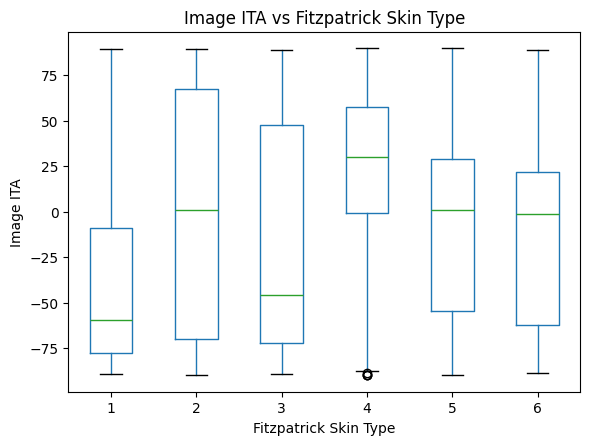

<Figure size 800x600 with 0 Axes>

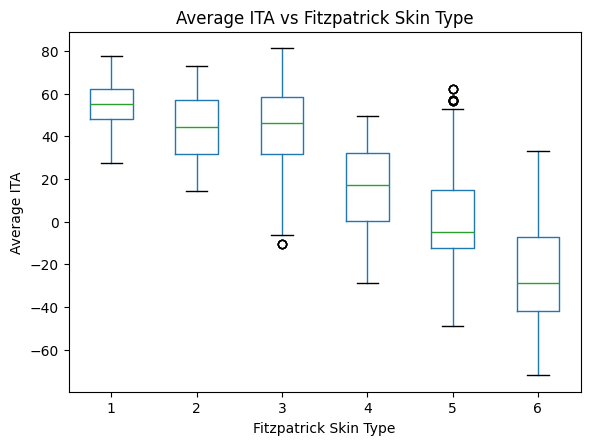

<Figure size 800x600 with 0 Axes>

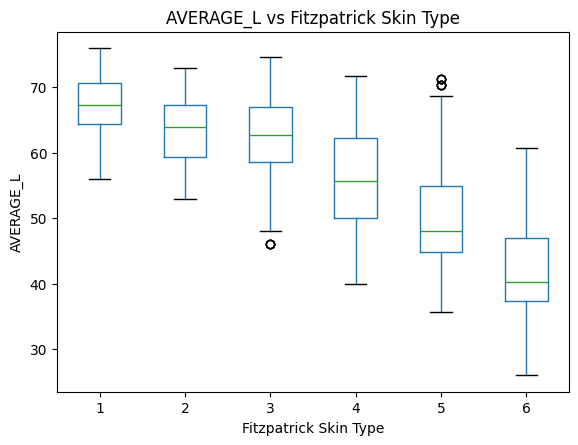

<Figure size 800x600 with 0 Axes>

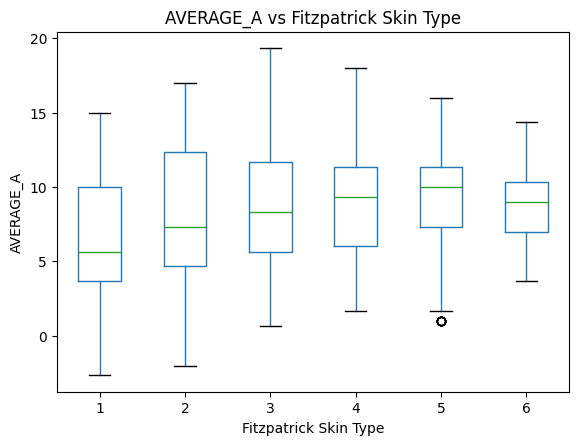

<Figure size 800x600 with 0 Axes>

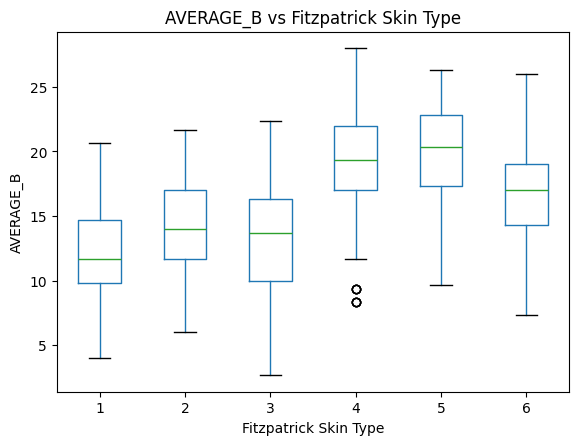

<Figure size 800x600 with 0 Axes>

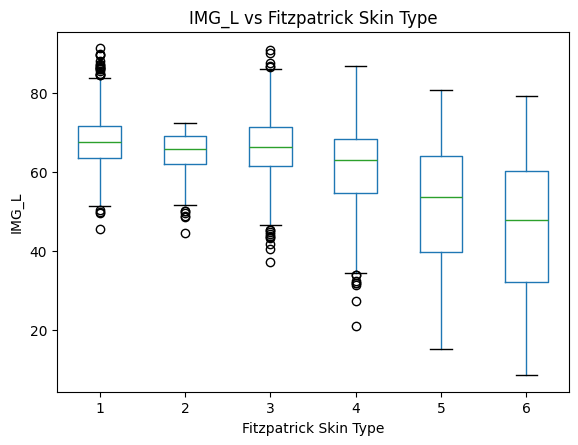

<Figure size 800x600 with 0 Axes>

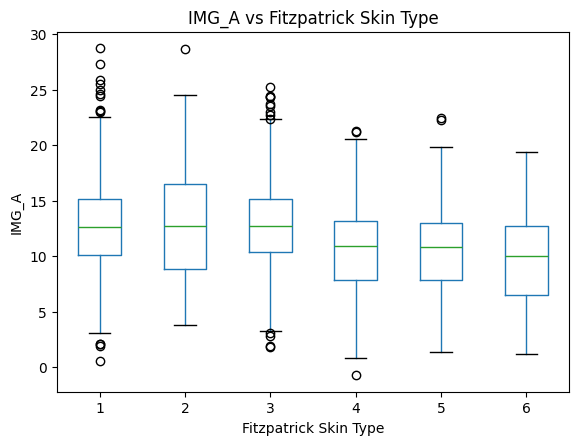

<Figure size 800x600 with 0 Axes>

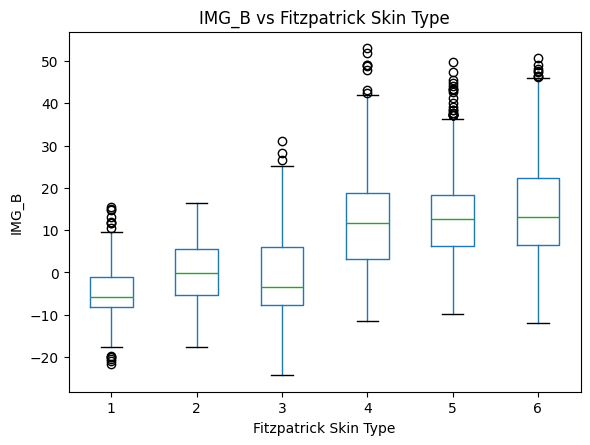

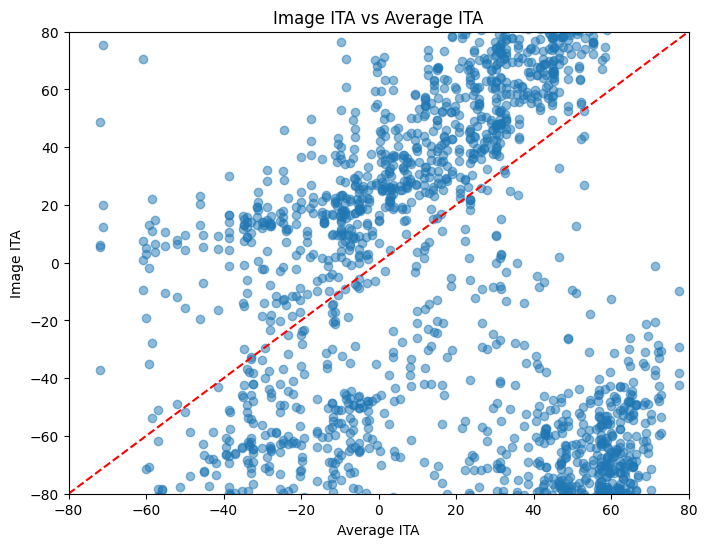

In [16]:
# plot image ita vs fitzpatrick
 
# ['IV' 'II' 'V' 'VI' 'I' 'III'] are the fitzpatrick skin types in the dataset
skin_type_mapping = {'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5, 'VI': 6}
combined_df['fitzpatrick_skin_type_num'] = combined_df['fitzpatrick_skin_type'].map(skin_type_mapping)

# img_ita, fitzpatrick_skin_type, box plot
plt.figure(figsize=(8, 6))
combined_df.boxplot(column='img_ita', by='fitzpatrick_skin_type_num', grid=False)
plt.title('Image ITA vs Fitzpatrick Skin Type')
plt.suptitle('')
plt.xlabel('Fitzpatrick Skin Type')
plt.ylabel('Image ITA')
plt.show()

# average_ita vs fitzpatrick_skin_type, box plot
plt.figure(figsize=(8, 6))
combined_df.boxplot(column='average_ita', by='fitzpatrick_skin_type_num', grid=False)
plt.title('Average ITA vs Fitzpatrick Skin Type')
plt.suptitle('')
plt.xlabel('Fitzpatrick Skin Type')
plt.ylabel('Average ITA')
plt.show()

# average_l, _a and _b vs fitzpatrick_skin_type, box plots
for channel in ['average_l', 'average_a', 'average_b']:
    plt.figure(figsize=(8, 6))
    combined_df.boxplot(column=channel, by='fitzpatrick_skin_type_num', grid=False)
    plt.title(f'{channel.upper()} vs Fitzpatrick Skin Type')
    plt.suptitle('')
    plt.xlabel('Fitzpatrick Skin Type')
    plt.ylabel(channel.upper())
    plt.show()


# img_l , _a and _b vs fitzpatrick_skin_type, box plots
for channel in ['img_l', 'img_a', 'img_b']:
    plt.figure(figsize=(8, 6))
    combined_df.boxplot(column=channel, by='fitzpatrick_skin_type_num', grid=False)
    plt.title(f'{channel.upper()} vs Fitzpatrick Skin Type')
    plt.suptitle('')
    plt.xlabel('Fitzpatrick Skin Type')
    plt.ylabel(channel.upper())
    plt.show()


# plot correlation between img_ita and average_ita
plt.figure(figsize=(8, 6))
plt.scatter(combined_df['average_ita'], combined_df['img_ita'], alpha=0.5)
plt.title('Image ITA vs Average ITA')
plt.ylabel('Image ITA')
plt.xlabel('Average ITA')
# scale -80 to 80 both axes
plt.xlim(-80, 80)
plt.ylim(-80, 80)
# show diagonal line
plt.plot([-80, 80], [-80, 80], color='red', linestyle='--')
plt.show()

In [ ]:
# would white balancing help here?

## Compare White Balancing on MSKCC Dataset

In [10]:
import sys
sys.path.append('/home/marinbenc/Projects/nn_dermatoscopy_colorimetry')

from fp_dataset import FPDataset
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
import cv2 as cv
import pandas as pd
import os

# Load MSKCC dataset without white balancing
dataset_no_wb = FPDataset('mskcc', files=None, blur_amount=0, white_balance=False)

# Load MSKCC dataset with white balancing
dataset_wb = FPDataset('mskcc', files=None, blur_amount=0, white_balance=True)

# Load GT color data from s7.csv
s7_df = pd.read_csv('data/mskcc/s7.csv')

print(f"Dataset loaded: {len(dataset_no_wb)} images")
print(f"Fitzpatrick types distribution: {np.bincount([fp+1 for fp in dataset_no_wb.fps])}")

[FPDataset] Found all resized images for mskcc in mskcc_processed.
[FPDataset] 4879 processed files found for mskcc out of 4879 total entries.
[FPDataset] Found all resized images for mskcc in mskcc_processed.
[FPDataset] 4879 processed files found for mskcc out of 4879 total entries.
Dataset loaded: 4879 images
Fitzpatrick types distribution: [  0   0 789 950 794 783 813 750]


In [11]:
# Group indices by Fitzpatrick type
fp_indices = {fp: [] for fp in range(1, 7)}
for idx, fp in enumerate(dataset_no_wb.fps):
    fp_indices[fp].append(idx)

# Sample 5 random examples from each Fitzpatrick type
samples_per_fp = {}
random.seed(42)
for fp in range(1, 7):
    if len(fp_indices[fp]) >= 5:
        samples_per_fp[fp] = random.sample(fp_indices[fp], 5)
    else:
        samples_per_fp[fp] = fp_indices[fp]
    print(f"FP Type {fp}: {len(fp_indices[fp])} images, sampling {len(samples_per_fp[fp])}")

samples_per_fp

FP Type 1: 789 images, sampling 5
FP Type 2: 950 images, sampling 5
FP Type 3: 794 images, sampling 5
FP Type 4: 783 images, sampling 5
FP Type 5: 813 images, sampling 5
FP Type 6: 750 images, sampling 5


{1: [4155, 734, 200, 4724, 1726],
 2: [1226, 1130, 653, 3724, 476],
 3: [4302, 4664, 3434, 597, 3770],
 4: [2783, 166, 160, 571, 1411],
 5: [1356, 3124, 3655, 174, 3493],
 6: [1443, 4714, 4263, 4647, 3616]}

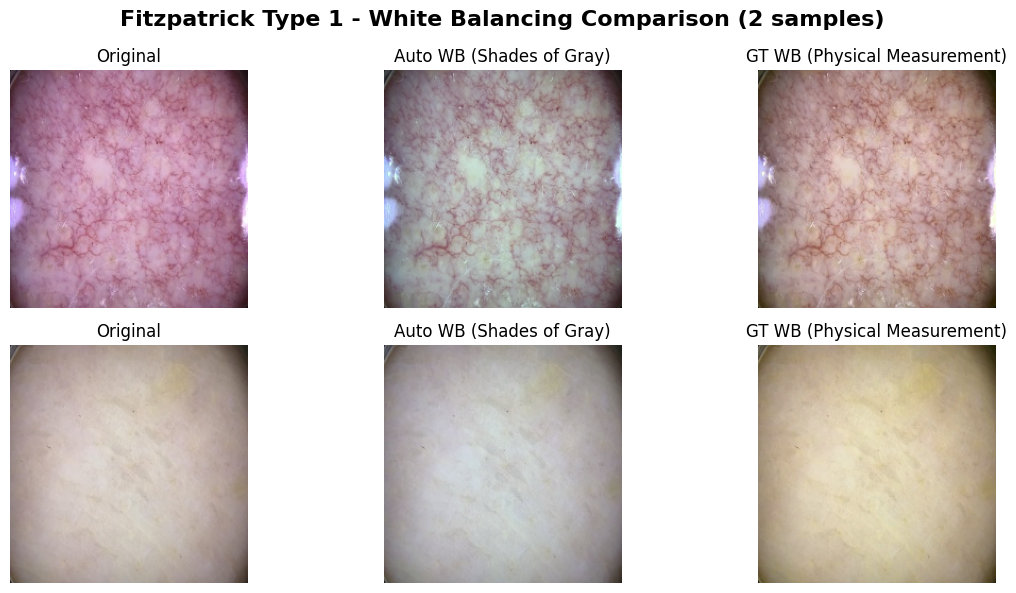

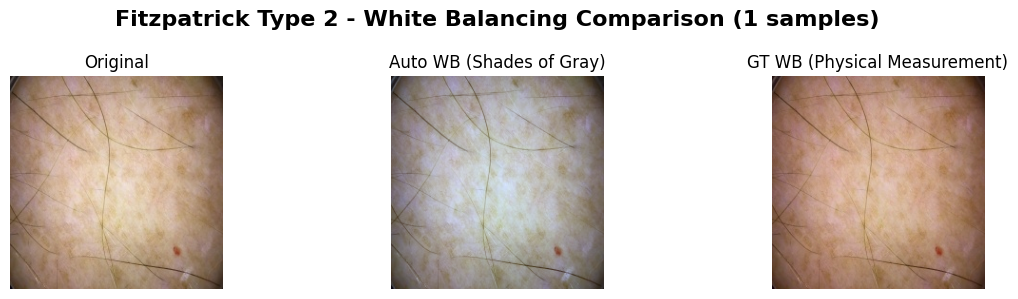

FP Type 3: No samples with GT data available
FP Type 4: No samples with GT data available


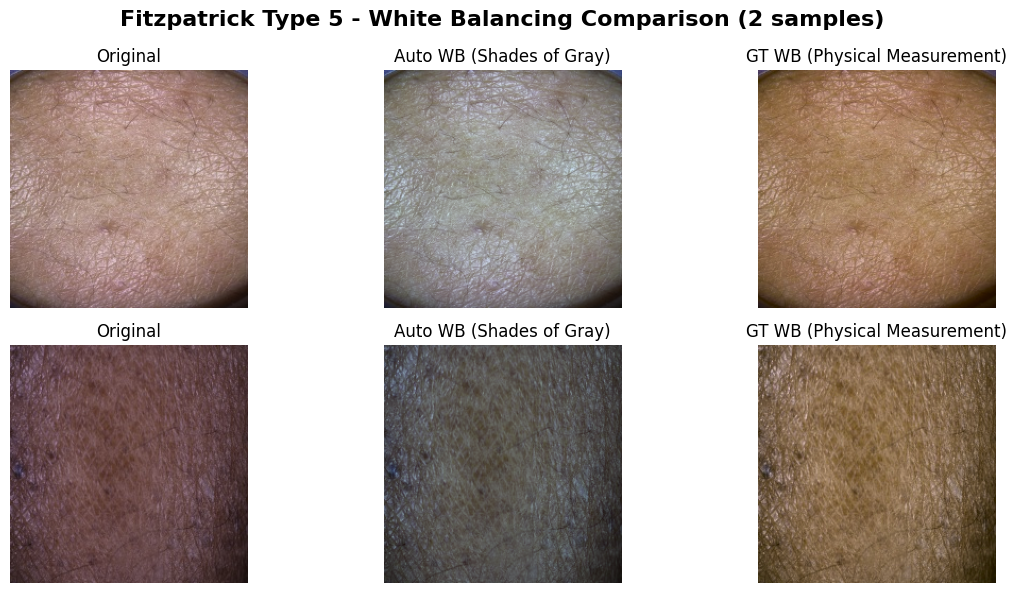

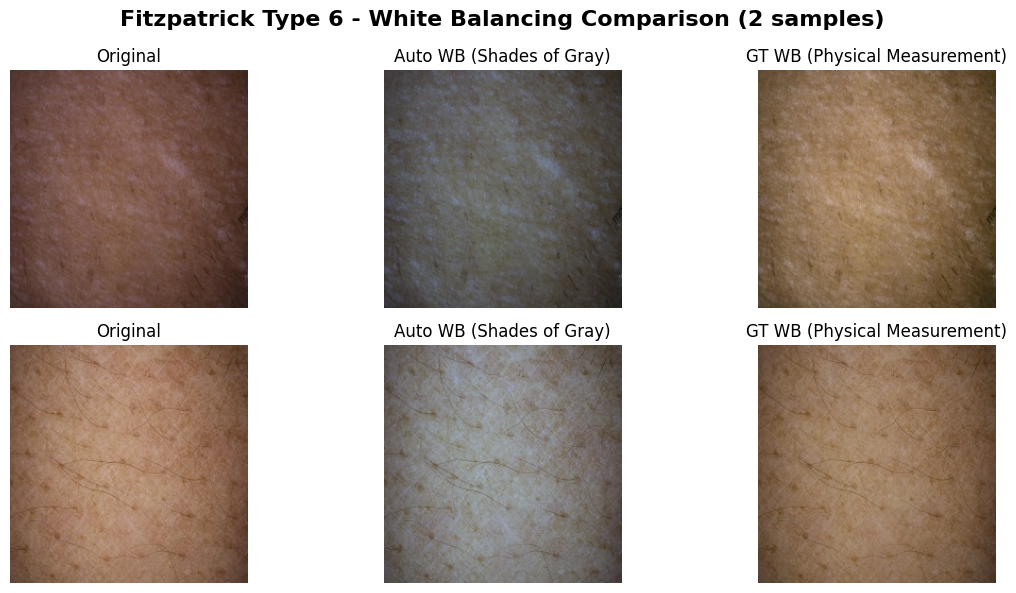

In [17]:
# Visualize before and after white balancing for each Fitzpatrick type (only images with GT data)
for fp in range(1, 7):
    samples = samples_per_fp[fp]
    n_samples = len(samples)
    
    if n_samples == 0:
        continue
    
    # Filter samples to only those with GT data in s7.csv
    valid_samples = []
    for idx in samples:
        orig_file = dataset_no_wb.orig_files[idx]
        isic_id = os.path.basename(orig_file).replace('.jpg', '')
        gt_row = s7_df[s7_df['isic_id'] == isic_id]
        if not gt_row.empty:
            valid_samples.append(idx)
    
    if len(valid_samples) == 0:
        print(f"FP Type {fp}: No samples with GT data available")
        continue
    
    n_samples = len(valid_samples)
    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 3*n_samples))
    fig.suptitle(f'Fitzpatrick Type {fp} - White Balancing Comparison ({n_samples} samples)', fontsize=16, fontweight='bold')
    
    if n_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(valid_samples):
        # Get original file path and ISIC ID
        orig_file = dataset_no_wb.orig_files[idx]
        isic_id = os.path.basename(orig_file).replace('.jpg', '')
        
        # Get GT color data for this image
        gt_row = s7_df[s7_df['isic_id'] == isic_id]
        
        # Get image without white balancing
        img_no_wb, _ = dataset_no_wb[idx]
        # Convert from normalized tensor back to displayable image
        img_no_wb = img_no_wb.permute(1, 2, 0).numpy()
        img_no_wb = img_no_wb * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_no_wb = np.clip(img_no_wb, 0, 1)
        
        # Get image with automatic white balancing
        img_wb, _ = dataset_wb[idx]
        # Convert from normalized tensor back to displayable image
        img_wb = img_wb.permute(1, 2, 0).numpy()
        img_wb = img_wb * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_wb = np.clip(img_wb, 0, 1)
        
        # Load original processed image
        processed_path = dataset_no_wb.get_processed_path(orig_file)
        img_original = cv.imread(processed_path)
        img_original = cv.cvtColor(img_original, cv.COLOR_BGR2RGB)
        
        # Get color values from GT data
        color_in_img = gt_row[['img_l', 'img_a', 'img_b']].values[0].copy()
        color_physical = gt_row[['average_l', 'average_a', 'average_b']].values[0].copy()
        
        # Map to OpenCV LAB range
        color_in_img[0] = color_in_img[0] * (255 / 100)
        color_in_img[1] = color_in_img[1] + 128
        color_in_img[2] = color_in_img[2] + 128
        
        color_physical[0] = color_physical[0] * (255 / 100)
        color_physical[1] = color_physical[1] + 128
        color_physical[2] = color_physical[2] + 128
        
        # Calculate correction value
        correction_value = color_physical / color_in_img
        
        # Apply correction to the image
        img_lab = cv.cvtColor(img_original, cv.COLOR_RGB2LAB).astype(np.float32)
        img_lab[:, :, 0] = img_lab[:, :, 0] * correction_value[0]
        img_lab[:, :, 1] = img_lab[:, :, 1] * correction_value[1]
        img_lab[:, :, 2] = img_lab[:, :, 2] * correction_value[2]
        img_lab = np.clip(img_lab, 0, 255).astype(np.uint8)
        img_gt_wb = cv.cvtColor(img_lab, cv.COLOR_LAB2RGB)
        img_gt_wb = img_gt_wb / 255.0  # Normalize to [0, 1]
        
        # Display
        axes[i, 0].imshow(img_no_wb)
        axes[i, 0].set_title('Original')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(img_wb)
        axes[i, 1].set_title('Auto WB (Shades of Gray)')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(img_gt_wb)
        axes[i, 2].set_title('GT WB (Physical Measurement)')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

[FPDataset] Found all resized images for mskcc in mskcc_processed.
[LabDataset] 1838 processed files found for mskcc out of 1838 total entries.
LabDataset loaded: 1838 images
ITA statistics:
  Mean: 17.85
  Std: 34.70
  Min: -72.08
  Max: 80.16


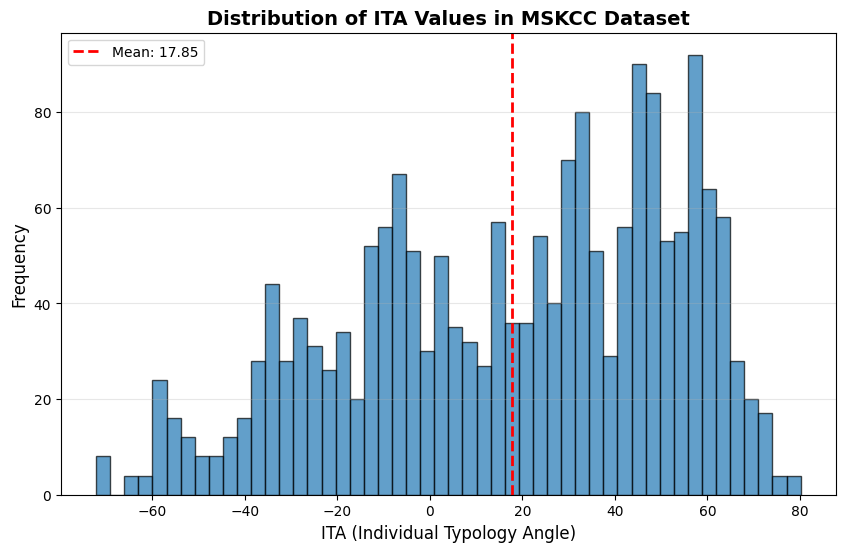

/tmp/ipykernel_3881666/3266273646.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(ita_data, labels=fp_types)


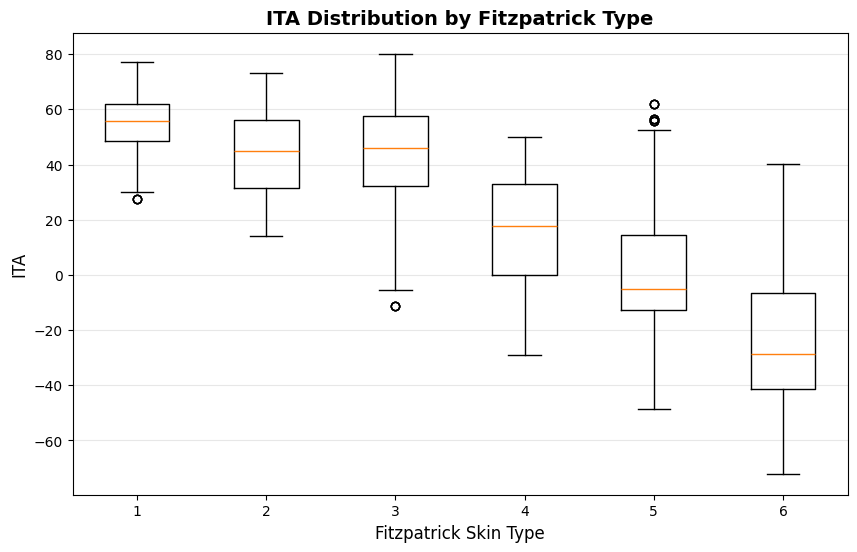

In [16]:
# Load LabDataset and plot ITA distribution
from lab_dataset import LabDataset

# Load the dataset
lab_dataset = LabDataset('mskcc', files=None, blur_amount=0, white_balance=False)

print(f"LabDataset loaded: {len(lab_dataset)} images")

# Extract LAB values
lab_values = np.array(lab_dataset.lab_values)
l_values = lab_values[:, 0]
a_values = lab_values[:, 1]
b_values = lab_values[:, 2]

# Calculate ITA: ITA = arctan((L* - 50) / b*) * 180 / π
ita_values = np.arctan2((l_values - 50), b_values) * 180 / np.pi

print(f"ITA statistics:")
print(f"  Mean: {ita_values.mean():.2f}")
print(f"  Std: {ita_values.std():.2f}")
print(f"  Min: {ita_values.min():.2f}")
print(f"  Max: {ita_values.max():.2f}")

# Plot ITA distribution
plt.figure(figsize=(10, 6))
plt.hist(ita_values, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('ITA (Individual Typology Angle)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of ITA Values in MSKCC Dataset', fontsize=14, fontweight='bold')
plt.axvline(ita_values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {ita_values.mean():.2f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Plot ITA by Fitzpatrick type
plt.figure(figsize=(10, 6))
ita_by_fp = {fp: [] for fp in range(1, 7)}
for idx, fp in enumerate(lab_dataset.fps):
    ita_by_fp[fp].append(ita_values[idx])

fp_types = list(ita_by_fp.keys())
ita_data = [ita_by_fp[fp] for fp in fp_types]

plt.boxplot(ita_data, labels=fp_types)
plt.xlabel('Fitzpatrick Skin Type', fontsize=12)
plt.ylabel('ITA', fontsize=12)
plt.title('ITA Distribution by Fitzpatrick Type', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

Loading LabDataset (only images with s7.csv data)...
[FPDataset] Found all resized images for mskcc in mskcc_processed.
[LabDataset] 1838 processed files found for mskcc out of 1838 total entries.
[FPDataset] Found all resized images for mskcc in mskcc_processed.
[FPDataset] 4879 processed files found for mskcc out of 4879 total entries.
Processing 1838 images...

Successfully processed: 1838 images

WHITE BALANCING METRICS

--- Auto WB vs GT WB ---
MSE:      1145.30 ± 1039.96
PSNR:     19.12 ± 3.77 dB
SSIM:     0.9336 ± 0.0748
Delta E:  28.55 ± 13.20

--- Original vs GT WB ---
MSE:      937.04 ± 1048.47
PSNR:     20.79 ± 4.76 dB
SSIM:     0.9470 ± 0.0716
Delta E:  27.49 ± 14.10

--- Improvement (Original → Auto WB) ---
MSE reduction:      -22.23% (worse)
PSNR improvement:   -1.67 dB (worse)
SSIM improvement:   -0.0134 (worse)
Delta E reduction:  -3.85% (worse)


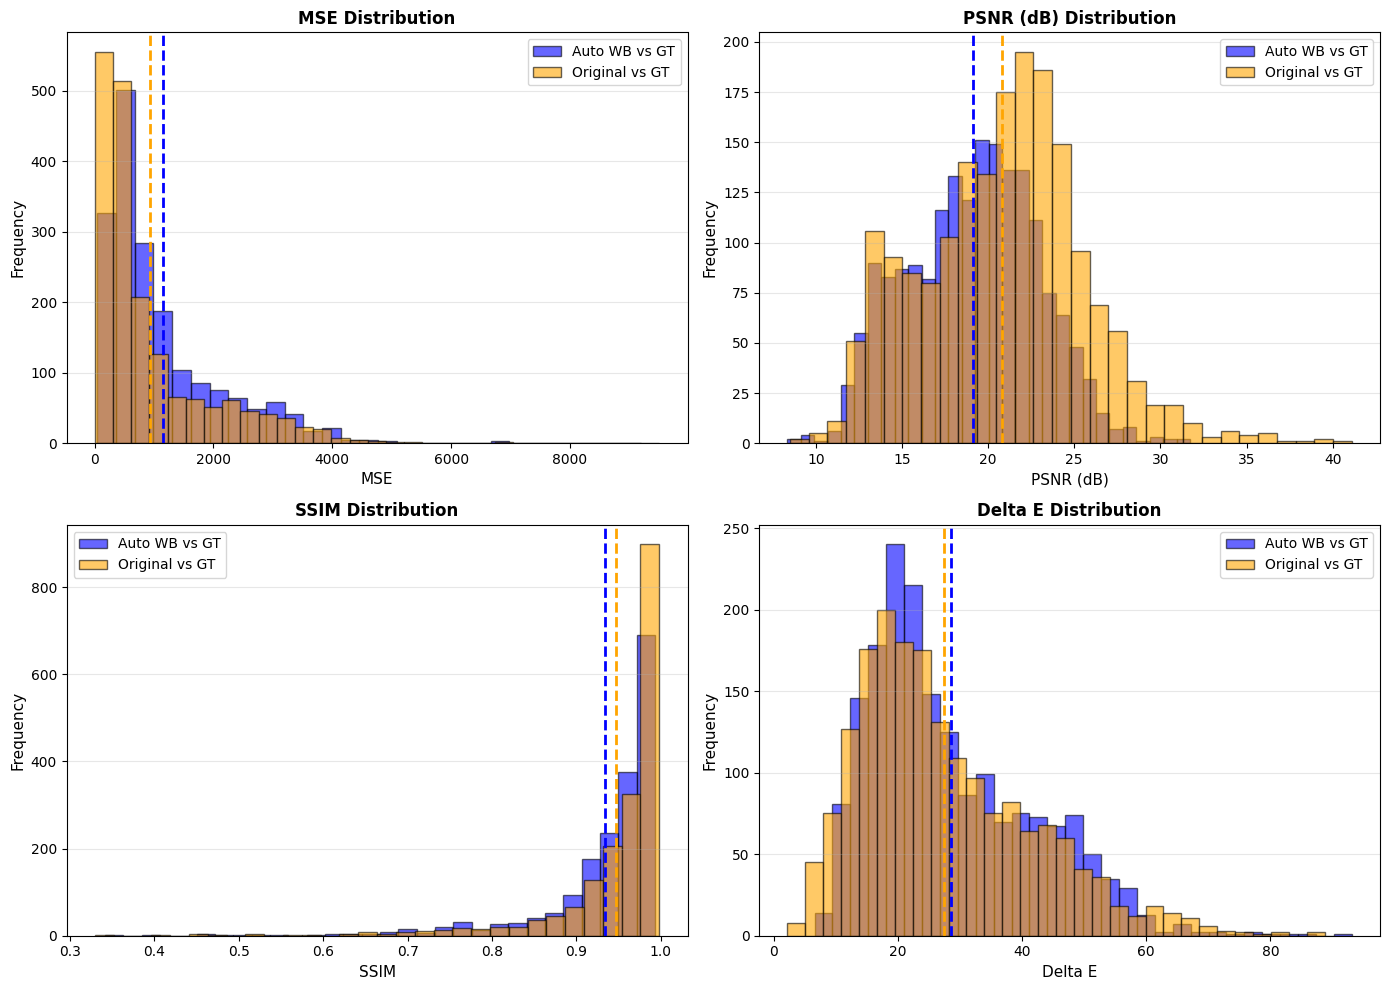

In [18]:
# Calculate white balancing metrics between auto/original and GT for all images in s7.csv
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import mean_squared_error as mse
from scipy.spatial.distance import euclidean
import warnings
warnings.filterwarnings('ignore')

def calculate_delta_e(img1_rgb, img2_rgb):
    """Calculate mean Delta E (CIE76) between two RGB images in LAB space"""
    # Convert to LAB
    img1_lab = cv.cvtColor(img1_rgb, cv.COLOR_RGB2LAB).astype(np.float32)
    img2_lab = cv.cvtColor(img2_rgb, cv.COLOR_RGB2LAB).astype(np.float32)
    
    # Calculate Delta E for each pixel
    delta_e = np.sqrt(
        (img1_lab[:,:,0] - img2_lab[:,:,0])**2 +
        (img1_lab[:,:,1] - img2_lab[:,:,1])**2 +
        (img1_lab[:,:,2] - img2_lab[:,:,2])**2
    )
    
    return delta_e.mean()

# Use lab_dataset which only contains images with GT data
print("Loading LabDataset (only images with s7.csv data)...")
lab_dataset = LabDataset('mskcc', files=None, blur_amount=0, white_balance=False)
dataset_wb = FPDataset('mskcc', files=None, blur_amount=0, white_balance=True)

print(f"Processing {len(lab_dataset)} images...")

# Store metrics
metrics_auto_vs_gt = {'mse': [], 'psnr': [], 'ssim': [], 'delta_e': []}
metrics_orig_vs_gt = {'mse': [], 'psnr': [], 'ssim': [], 'delta_e': []}
failed_images = []

for idx in range(len(lab_dataset)):
    try:
        orig_file = lab_dataset.orig_files[idx]
        isic_id = os.path.basename(orig_file).replace('.jpg', '')
        
        # Get GT data
        gt_row = s7_df[s7_df['isic_id'] == isic_id]
        if gt_row.empty:
            continue
        
        # Load original processed image (uint8, 0-255)
        processed_path = lab_dataset.get_processed_path(orig_file)
        img_original = cv.imread(processed_path)
        img_original = cv.cvtColor(img_original, cv.COLOR_BGR2RGB)
        
        # Apply GT white balancing
        color_in_img = gt_row[['img_l', 'img_a', 'img_b']].values[0].copy()
        color_physical = gt_row[['average_l', 'average_a', 'average_b']].values[0].copy()
        
        # Map to OpenCV LAB range
        color_in_img[0] = color_in_img[0] * (255 / 100)
        color_in_img[1] = color_in_img[1] + 128
        color_in_img[2] = color_in_img[2] + 128
        
        color_physical[0] = color_physical[0] * (255 / 100)
        color_physical[1] = color_physical[1] + 128
        color_physical[2] = color_physical[2] + 128
        
        correction_value = color_physical / color_in_img
        
        img_lab = cv.cvtColor(img_original, cv.COLOR_RGB2LAB).astype(np.float32)
        img_lab[:, :, 0] = img_lab[:, :, 0] * correction_value[0]
        img_lab[:, :, 1] = img_lab[:, :, 1] * correction_value[1]
        img_lab[:, :, 2] = img_lab[:, :, 2] * correction_value[2]
        img_lab = np.clip(img_lab, 0, 255).astype(np.uint8)
        img_gt_wb = cv.cvtColor(img_lab, cv.COLOR_LAB2RGB)
        
        # Apply auto white balancing (using dataset_wb which applies shades_of_grey_wb)
        from white_balance import shades_of_grey_wb
        img_auto_wb = shades_of_grey_wb(img_original, p=6)
        img_auto_wb = (img_auto_wb * 255).astype(np.uint8)
        
        # Calculate metrics: Auto WB vs GT WB
        metrics_auto_vs_gt['mse'].append(mse(img_auto_wb, img_gt_wb))
        metrics_auto_vs_gt['psnr'].append(psnr(img_gt_wb, img_auto_wb, data_range=255))
        metrics_auto_vs_gt['ssim'].append(ssim(img_gt_wb, img_auto_wb, channel_axis=2, data_range=255))
        metrics_auto_vs_gt['delta_e'].append(calculate_delta_e(img_auto_wb, img_gt_wb))
        
        # Calculate metrics: Original vs GT WB
        metrics_orig_vs_gt['mse'].append(mse(img_original, img_gt_wb))
        metrics_orig_vs_gt['psnr'].append(psnr(img_gt_wb, img_original, data_range=255))
        metrics_orig_vs_gt['ssim'].append(ssim(img_gt_wb, img_original, channel_axis=2, data_range=255))
        metrics_orig_vs_gt['delta_e'].append(calculate_delta_e(img_original, img_gt_wb))
        
    except Exception as e:
        failed_images.append((isic_id, str(e)))
        continue

print(f"\nSuccessfully processed: {len(metrics_auto_vs_gt['mse'])} images")
if failed_images:
    print(f"Failed: {len(failed_images)} images")

# Display results
print("\n" + "="*60)
print("WHITE BALANCING METRICS")
print("="*60)

print("\n--- Auto WB vs GT WB ---")
print(f"MSE:      {np.mean(metrics_auto_vs_gt['mse']):.2f} ± {np.std(metrics_auto_vs_gt['mse']):.2f}")
print(f"PSNR:     {np.mean(metrics_auto_vs_gt['psnr']):.2f} ± {np.std(metrics_auto_vs_gt['psnr']):.2f} dB")
print(f"SSIM:     {np.mean(metrics_auto_vs_gt['ssim']):.4f} ± {np.std(metrics_auto_vs_gt['ssim']):.4f}")
print(f"Delta E:  {np.mean(metrics_auto_vs_gt['delta_e']):.2f} ± {np.std(metrics_auto_vs_gt['delta_e']):.2f}")

print("\n--- Original vs GT WB ---")
print(f"MSE:      {np.mean(metrics_orig_vs_gt['mse']):.2f} ± {np.std(metrics_orig_vs_gt['mse']):.2f}")
print(f"PSNR:     {np.mean(metrics_orig_vs_gt['psnr']):.2f} ± {np.std(metrics_orig_vs_gt['psnr']):.2f} dB")
print(f"SSIM:     {np.mean(metrics_orig_vs_gt['ssim']):.4f} ± {np.std(metrics_orig_vs_gt['ssim']):.4f}")
print(f"Delta E:  {np.mean(metrics_orig_vs_gt['delta_e']):.2f} ± {np.std(metrics_orig_vs_gt['delta_e']):.2f}")

# Improvement analysis
print("\n--- Improvement (Original → Auto WB) ---")
mse_improvement = ((np.mean(metrics_orig_vs_gt['mse']) - np.mean(metrics_auto_vs_gt['mse'])) / 
                   np.mean(metrics_orig_vs_gt['mse']) * 100)
psnr_improvement = np.mean(metrics_auto_vs_gt['psnr']) - np.mean(metrics_orig_vs_gt['psnr'])
ssim_improvement = np.mean(metrics_auto_vs_gt['ssim']) - np.mean(metrics_orig_vs_gt['ssim'])
delta_e_improvement = ((np.mean(metrics_orig_vs_gt['delta_e']) - np.mean(metrics_auto_vs_gt['delta_e'])) / 
                       np.mean(metrics_orig_vs_gt['delta_e']) * 100)

print(f"MSE reduction:      {mse_improvement:.2f}% {'(better)' if mse_improvement > 0 else '(worse)'}")
print(f"PSNR improvement:   {psnr_improvement:+.2f} dB {'(better)' if psnr_improvement > 0 else '(worse)'}")
print(f"SSIM improvement:   {ssim_improvement:+.4f} {'(better)' if ssim_improvement > 0 else '(worse)'}")
print(f"Delta E reduction:  {delta_e_improvement:.2f}% {'(better)' if delta_e_improvement > 0 else '(worse)'}")

# Plot metric distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_names = ['MSE', 'PSNR (dB)', 'SSIM', 'Delta E']
metrics_keys = ['mse', 'psnr', 'ssim', 'delta_e']

for idx, (name, key) in enumerate(zip(metrics_names, metrics_keys)):
    ax = axes[idx // 2, idx % 2]
    
    ax.hist(metrics_auto_vs_gt[key], bins=30, alpha=0.6, label='Auto WB vs GT', color='blue', edgecolor='black')
    ax.hist(metrics_orig_vs_gt[key], bins=30, alpha=0.6, label='Original vs GT', color='orange', edgecolor='black')
    
    ax.axvline(np.mean(metrics_auto_vs_gt[key]), color='blue', linestyle='--', linewidth=2)
    ax.axvline(np.mean(metrics_orig_vs_gt[key]), color='orange', linestyle='--', linewidth=2)
    
    ax.set_xlabel(name, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{name} Distribution', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()